In [10]:
#Copyright (c) 2023 John Simonis and The Ohio State University. All rights reserved.
#This code was written by John Simonis for a research project at The Ohio State University.

#This is what we use for our equations of best fit.
from pysr import PySRRegressor

#Necessary for handling symbolic outputs of pysr.
import sympy

#Let us import data into a dataframe.
import pandas as pd

#Arrays, interpolation, and analysis.
import numpy as np

#Needed for plotting.
from matplotlib import pyplot as plt

#Needed for data skew.
import scipy as sp

#This is a dictionary of a handful of customized PYSR terms, see here https://astroautomata.com/PySR/
default_pysr_params = dict(
    populations=50,
    model_selection="accuracy",
    population_size=100,
    niterations=100,
    binary_operators=["+", "*", "^"],
    unary_operators=["sin", "cos", "exp", "log", "erf", "ceil", "floor"],
    maxsize=50,
    ncycles_per_iteration=100,
    progress=False,
    procs=10,
    variable_names=["x", "y"],
)

#Control Dataset
Control_XLS = pd.ExcelFile("../Control/DessicantControlTests.xlsx")
Control_Dataframe = pd.read_excel(Control_XLS, sheet_name="Average")

#Proto Dataset
Proto_XLS = pd.ExcelFile("../Proto/ProtoTests.xlsx")
Proto_Dataframe = pd.read_excel(Proto_XLS, sheet_name="Average")

#Dep Control Dataset
DepControl_XLS = pd.ExcelFile("../Deprecated/DCTests.xlsx")
DepControl_Dataframe = pd.read_excel(
    DepControl_XLS,
    sheet_name="Average",
    names=[
        "Amps (A)",
        "Water Level (mL)",
        "Volts (V)",
        "WattHours (WH)",
        "Temp (C)",
        "Relative Humidity (%)",
        "Cumulative WattHours (WH)",
    ],
)

#Dep Proto Dataset
DepProto_XLS = pd.ExcelFile("../Deprecated/DPTests.xlsx")
DepProto_Dataframe = pd.read_excel(
    DepProto_XLS,
    sheet_name="Average",
    names=[
        "Amps (A)",
        "Water Level (mL)",
        "Volts (V)",
        "WattHours (WH)",
        "Temp (C)",
        "Relative Humidity (%)",
        "Cumulative WattHours (WH)",
    ],
)


#Control Variables
C_x = Control_Dataframe["WattHours (WH)"].to_numpy().reshape(-1, 1)
C_y = Control_Dataframe["Water Level (mL)"].to_numpy()
C_z = Control_Dataframe["Temp (C)"].to_numpy()

#Proto Variables
P_x = Proto_Dataframe["WattHours (WH)"].to_numpy().reshape(-1, 1)
P_y = Proto_Dataframe["Water Level (mL)"].to_numpy()
P_z = Proto_Dataframe["Temp (C)"].to_numpy()

#Dep Control Variables
DC_x = (
    pd.to_numeric(
        DepControl_Dataframe["WattHours (WH)"].str.replace(" WH", "")
    )
    .to_numpy()
    .reshape(-1, 1)
)

DC_y = pd.to_numeric(DepControl_Dataframe["Water Level (mL)"].str.replace(" mL", "")).to_numpy()
DC_z = pd.to_numeric(DepControl_Dataframe["Temp (C)"].str.replace(" C", "")).to_numpy()

#Dep Proto Variables
DP_x = (
    pd.to_numeric(
        DepProto_Dataframe["WattHours (WH)"].str.replace(" WH", "")
    )
    .to_numpy()
    .reshape(-1, 1)
)

DP_y = pd.to_numeric(DepProto_Dataframe["Water Level (mL)"].str.replace(" mL", "")).to_numpy()
DP_z = pd.to_numeric(DepProto_Dataframe["Temp (C)"].str.replace(" C", "")).to_numpy()

def analysis(data):
    data_headers = ["Vertical Power", "Vertical Temp", "Vertical Amp", "Vertical Water"]
    for i in range(0, 4):
        print(data_headers[i], "STDDEV:", np.std(data[i]))
        print(data_headers[i], "MEDIAN:", np.median(data[i]))
        print(data_headers[i], "SKEW:", sp.stats.skew(data[i]), "\n")

## Dessicant Wheel Control
The Control Water Harvester utilizes a desiccant wheel design, leveraging a heat lamp to dry out pockets of desiccant and a fan to circulate heated air through the silica gel desiccant.

In [11]:
#Pass in the fitting parameters
Control_Equations = PySRRegressor(
    **default_pysr_params,
)

#Fit an equation to the data
Control_Equations.fit(C_x, C_y)

/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:922: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:1290: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:73: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://astroautomata.com/PySR/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.680e+05
Head worker occupation: 25.9%
Progress: 1038 / 5000 total iterations (20.760%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
2           1.757e+01  7.971e+00  y = exp(2.05)
4           1.751e+01  1.587e-03  y = floor(x₀ ^ -3.1714)
5           1.747e+01  2.601e-03  y = 61.241 + (-104 * x₀)
6           1.746e+01  2.577e-04  y = floor((x₀ * -103.7) + 61.757)
10          1.745e+01  1.275e-04  y = ceil(floor(ceil(61.241) + (x₀ * -104))) + -0.24949
12          1.742e+01  8.597e-04  y = ceil(ceil((61.241 + floor(floor(floor(x₀ * -104)))) ^ 1.04...
                                  65))
14          1.741e+01  3.651e-04  y = -12.365 + ceil(exp((x₀ ^ log(sin(x₀ * x₀))) + erf(x₀)))
19          1.741e+01  1.277e-05  y = floor(ceil(exp((cos(x₀) + exp(ceil(x₀))) + exp(ceil(x₀))) ...
                                  + 0.23173)) + (-541.88 + x₀)
21

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                                 x0   
	1         1.385209                                     exp(2.0500424)   
	2         0.004030                                    x0 ^ -3.0822768   
	3         0.000873                       61.29413 + (-104.10543 * x0)   
	4         0.003218                   ceil(x0 * -177.47672) + 98.63513   
	5         0.000410  101.823135 + ((x0 * 36.610477) + ceil(-220.364...   
	6         0.000133  ((x0 * 56.89697) + ceil(-193.1123 * x0)) + (58...   
	7         0.000002  (ceil(-193.1123 * x0) + (x0 * 56.89697)) + ((5...   
	8         0.000904  130.97621 + (ceil(x0 * -120.24569) + (sin(65.4...   
	9         0.000646  130.97621 + (ceil(x0 * -120.24569) + (sin(65.4...   
	10        0.000141  130.97621 + (ceil(x0 * -120.24569) + (sin(65.4...   
	11  >>>>  0.000050  130.97621 + (ceil(x0 * -120.24569) + (sin(65.4...   
	
	         loss  complexity  
	0   70.195860           1  
	1   17.568020           2  
	2   17.497372           3  
	3   17.466846           5  
	4   17.410736           6  
	5   17.382174          10  
	6   17.377554          12  
	7   17.377472          14  
	8   17.330400          17  
	9   17.319216          18  
	10  17.311888          21  
	11  17.310143          23  
]

Vertical Power STDDEV: 0.003055499438317472
Vertical Power MEDIAN: 0.5133333333333333
Vertical Power SKEW: 0.1908440289314235 

Vertical Temp STDDEV: 2.9918445133812783
Vertical Temp MEDIAN: 27.08
Vertical Temp SKEW: 0.00830511957701228 

Vertical Amp STDDEV: 0.023454447576336378
Vertical Amp MEDIAN: 7.713333333333334
Vertical Amp SKEW: -0.10235233214597493 

Vertical Water STDDEV: 4.191422343549114
Vertical Water MEDIAN: 7.333333333333333
Vertical Water SKEW: 0.13485310695774946 

- 120 x_{0} + \sin{\left(65.4 \left(0.996 + \left(x_{0} + 0.744\right) \left(-2.90 \cdot 10^{3}\right)\right) \right)} + \left\lceil{x_{0} \left(-120.\right)}\right\rceil + 131.


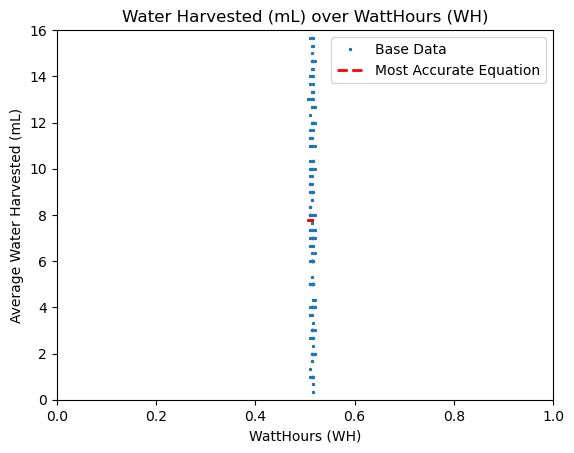

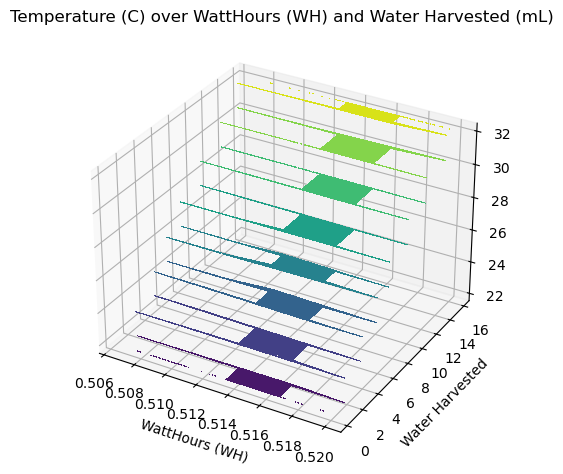

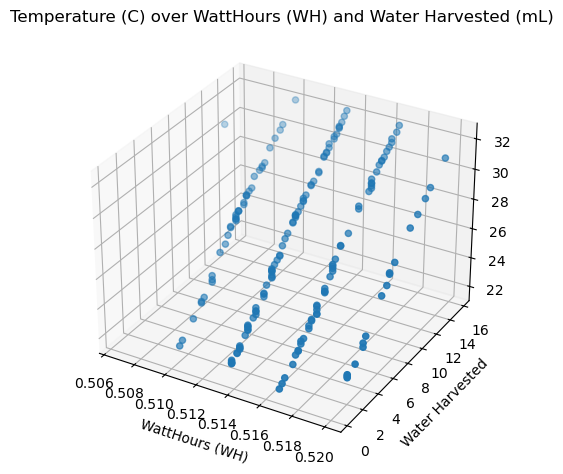

In [12]:
#Basic scatter plot
plt.plot(
    C_x,
    C_y,
    linewidth=2,
    linestyle="none",
    marker="*",
    label="Base Data",
    fillstyle="none",
    markersize=2,
)

#Fit the equation to the data
best_idx = Control_Equations.equations_.query(
    f"loss < {2 * Control_Equations.equations_.loss.min()}"
).score.idxmax()
plt.plot(
    C_x,
    Control_Equations.predict(C_x, index=best_idx),
    color="red",
    linestyle="dashed",
    linewidth=2,
    label="Most Accurate Equation",
)
plt.title("Water Harvested (mL) over WattHours (WH)")
plt.xlabel("WattHours (WH)")
plt.ylabel("Average Water Harvested (mL)")
plt.legend()
plt.xlim([0, 1])
plt.ylim([0, 16])
analysis(
    [
        Control_Dataframe["WattHours (WH)"].to_numpy(),
        C_z,
        Control_Dataframe["Amps (A)"].to_numpy(),
        C_y,
    ]
)
print(Control_Equations.latex())

#3D scatterplot and contour plot
fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over WattHours (WH) and Water Harvested (mL)")
plt.xlabel("WattHours (WH)")
plt.ylabel("Water Harvested")
fig.tight_layout()
C_X, C_Y = np.meshgrid(C_x,C_y)
C_Z = sp.interpolate.griddata(np.column_stack((C_x.reshape(-1,1),C_y)), C_z, (C_X, C_Y), method = "nearest")
plt.contourf(C_x.reshape(-1),C_y,C_Z)

fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over WattHours (WH) and Water Harvested (mL)")
plt.xlabel("WattHours (WH)")
plt.ylabel("Water Harvested")
fig.tight_layout()
ax.scatter3D(C_x,C_y,C_z)

# NiTi Prototype
The NiTi prototype employs a straightforward gantry system, powered by a high torque stepper motor. A T8 leadscrew is incorporated for a simple mechanical advantage to apply stress to the NiTi wires.

In [13]:
#Run PySR
Proto_Equations = PySRRegressor(
    **default_pysr_params,
)

#Fit an equation to the data
Proto_Equations.fit(P_x, P_y)

/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:922: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:1290: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:73: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://astroautomata.com/PySR/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.340e+05
Head worker occupation: 27.5%
Progress: 794 / 5000 total iterations (15.880%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
2           6.920e+00  7.971e+00  y = exp(1.5801)
4           6.920e+00  5.186e-06  y = 3.9311 + cos(x₀)
5           6.918e+00  2.043e-04  y = sin(cos(x₀)) + 4.0582
7           6.918e+00  1.630e-05  y = (cos(x₀) ^ sin(x₀)) + 3.8884
8           6.793e+00  1.832e-02  y = ceil(0.029656 + (exp(cos(x₀)) * 1.6972))
10          6.771e+00  1.571e-03  y = ceil(0.029656 + (1.6972 * exp(cos(x₀)))) + x₀
12          6.765e+00  4.654e-04  y = ceil(exp(cos(cos(x₀) * x₀)) ^ 1.5556) + sin(x₀)
13          6.740e+00  3.772e-03  y = (ceil(exp(cos(cos(x₀) * x₀)) ^ 1.5556) + x₀) + -0.18772
14          6.739e+00  1.444e-04  y = (ceil(exp(cos(cos(x₀) * x₀)) ^ 1.5556) + sin(x₀)) + -0.187...
                                  72
18       

PySRRegressor.equations_ = [
	    pick         score                                           equation  \
	0         0.000000e+00                                         0.88644636   
	1         1.186808e+00                                      exp(1.580124)   
	2         8.670676e-08                            -2.6911259 * -1.8043429   
	3         1.040487e-05                                3.9311373 + cos(x0)   
	4         2.133236e-04                           erf(cos(x0)) + 4.0491962   
	5         1.834122e-02                 ceil(4.44095 + (x0 * -0.79401356))   
	6         1.571426e-03                ceil(1.7086728 * exp(cos(x0))) + x0   
	7         9.309665e-04           ceil(1.7086728 * exp(cos(x0))) + sin(x0)   
	8         3.785009e-03  (ceil(1.7108315 * exp(cos(x0))) + -0.17840171)...   
	9         1.846175e-04  (ceil(1.7086728 * exp(cos(x0))) + -0.17817034)...   
	10        7.618359e-03  floor((x0 * exp(x0)) + ceil(1.7086728 * exp(co...   
	11        1.819882e-02  2.124952 * exp(cos(sin(floor(exp(exp(2.147038)...   
	12        1.931448e-03  2.124952 * exp(cos(sin(floor(floor(exp(exp(2.1...   
	13        1.353083e-04  2.147038 ^ exp(sin(cos(sin(floor(floor(exp(exp...   
	14        9.107396e-03  2.124952 * exp(cos(-0.37638327 + sin(x0 + exp(...   
	15        3.130632e-04  2.124952 ^ exp(erf(cos(sin(exp(exp(exp(cos(exp...   
	16        3.461475e-04  2.124952 ^ exp(erf(cos(sin(erf(x0) + exp(exp(e...   
	17        2.879698e-03  2.1369405 ^ exp(erf(cos(sin((exp(exp(exp(cos(e...   
	18        7.714264e-05  2.1369405 ^ exp(erf(cos(sin((exp(exp(exp(cos(e...   
	19        1.118077e-03  exp(sin(cos(sin((x0 ^ 0.51348555) + exp(exp(ex...   
	20        1.097404e-04  exp(sin(cos(sin((x0 ^ 0.51348555) + exp(exp(ex...   
	21        4.513622e-04  exp(sin(cos(sin((x0 + -0.31767195) + ceil(exp(...   
	22        1.114994e-06  exp(sin(cos(sin((x0 + sin(-0.31767195)) + ceil...   
	23        2.146749e-04  2.099217 ^ exp(sin(cos((sin(sin(ceil(sin(x0) *...   
	24        1.157031e-03  2.116857 ^ exp(erf(cos(-0.1688367 + sin(exp(ex...   
	25        1.638116e-03  2.116857 ^ exp(erf(cos(log(0.8247722) + sin(ex...   
	26        5.015104e-04  exp(erf(cos((-0.1688367 + sin(exp(exp((((exp(c...   
	27        1.351915e-03  exp(erf(cos((-0.1688367 + erf(sin(exp(exp(sin(...   
	28        3.841923e-04  exp(erf(cos((erf(sin(exp(exp(sin(x0) + (((x0 +...   
	29        2.400700e-06  exp(erf(cos(((sin(sin(-0.1688367)) + erf(sin(e...   
	30        3.159321e-04  exp(erf(cos(((-0.1688367 + erf(sin(exp(exp(sin...   
	31        1.374133e-04  exp(erf(cos(((-0.1688367 + erf(sin(exp(exp(sin...   
	32        1.381660e-04  exp(erf(cos(((-0.1688367 + erf(sin(exp(exp(sin...   
	33  >>>>  6.928349e-04  exp(erf(cos(sin(exp(cos(sin(ceil(exp(3.2050905...   
	
	         loss  complexity  
	0   22.673706           1  
	1    6.919876           2  
	2    6.919875           3  
	3    6.919803           4  
	4    6.918327           5  
	5    6.792593           6  
	6    6.771278           8  
	7    6.764977           9  
	8    6.739420          10  
	9    6.738176          11  
	10   6.687037          12  
	11   6.566442          13  
	12   6.553771          14  
	13   6.551112          17  
	14   6.491719          18  
	15   6.489687          19  
	16   6.487441          20  
	17   6.468786          21  
	18   6.468287          22  
	19   6.461059          23  
	20   6.460350          24  
	21   6.457435          25  
	22   6.457427          26  
	23   6.454656          28  
	24   6.439736          30  
	25   6.429196          31  
	26   6.425973          32  
	27   6.417291          33  
	28   6.414826          34  
	29   6.414764          38  
	30   6.406663          42  
	31   6.405783          43  
	32   6.404898          44  
	33   6.400462          45  
]

Vertical Power STDDEV: 0.2785496658115589
Vertical Power MEDIAN: 0.27
Vertical Power SKEW: 0.0014724439344308453 

Vertical Temp STDDEV: 0.14768078479453892
Vertical Temp MEDIAN: 23.511666666666663
Vertical Temp SKEW: -0.04108905149599962 

Vertical Amp STDDEV: 4.179428089587817
Vertical Amp MEDIAN: 4.045
Vertical Amp SKEW: 0.0012824667441691305 

Vertical Water STDDEV: 2.6305658218736663
Vertical Water MEDIAN: 5.0
Vertical Water SKEW: -0.11995470090320919 

\left(e^{\operatorname{erf}{\left(\cos{\left(\sin{\left(e^{\cos{\left(\sin{\left(\left\lceil{e^{x_{0} + 3.21}}\right\rceil^{x_{0}} \right)} \right)}} \right)} \left(\operatorname{erf}{\left(\sin{\left(\left(e^{e^{\left(x_{0} + e^{\cos{\left(e^{-0.0327} \right)}}\right)^{\sin{\left(x_{0} + 3.21 \right)} - 0.644} + \sin{\left(x_{0} \right)} + 3.50}}\right)^{x_{0}} \right)} \right)} - 0.169\right) 1.12 \right)} \right)}}\right)^{2.12}


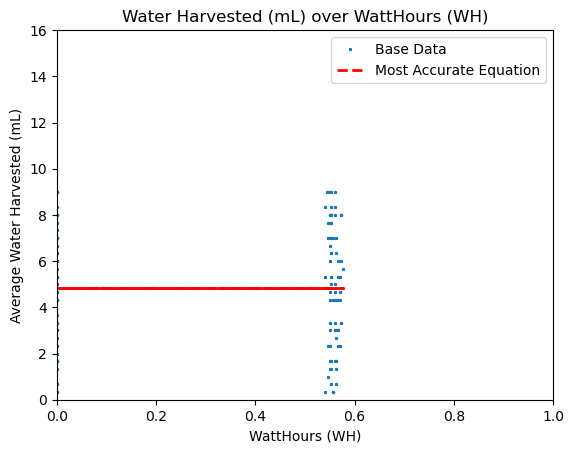

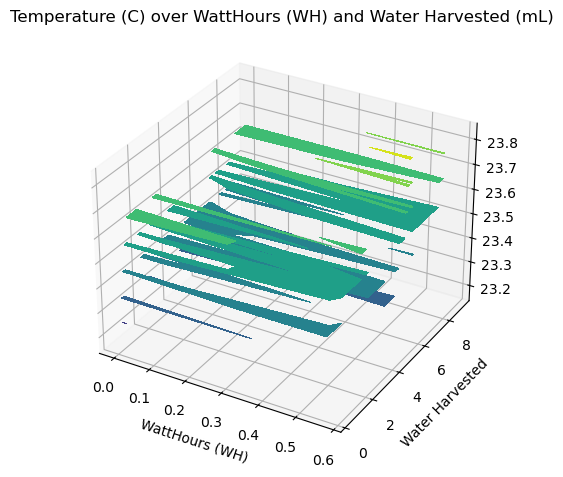

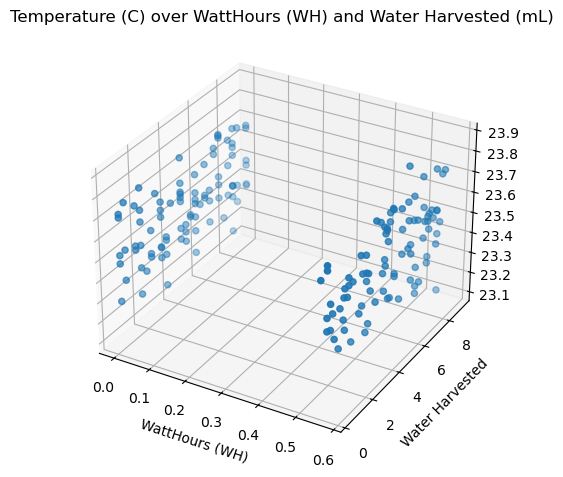

In [14]:
#Basic scatter plot
plt.plot(
    P_x,
    P_y,
    linewidth=2,
    linestyle="none",
    marker="*",
    label="Base Data",
    fillstyle="none",
    markersize=2,
)

#Fit the equation to the data
best_idx = Proto_Equations.equations_.query(
    f"loss < {2 * Proto_Equations.equations_.loss.min()}"
).score.idxmax()
plt.plot(
    P_x,
    Proto_Equations.predict(P_x, index=best_idx),
    color="red",
    linestyle="dashed",
    linewidth=2,
    label="Most Accurate Equation",
)
plt.title("Water Harvested (mL) over WattHours (WH)")
plt.xlabel("WattHours (WH)")
plt.ylabel("Average Water Harvested (mL)")
plt.legend()
plt.xlim([0, 1])
plt.ylim([0, 16])
analysis(
    [
        Proto_Dataframe["WattHours (WH)"].to_numpy(),
        P_z,
        Proto_Dataframe["Amps (A)"].to_numpy(),
        P_y,
    ]
)
print(Proto_Equations.latex())

#3D scatterplot and contour plot
fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over WattHours (WH) and Water Harvested (mL)")
plt.xlabel("WattHours (WH)", loc="left")
plt.ylabel("Water Harvested")
fig.tight_layout()
P_X, P_Y = np.meshgrid(P_x,P_y)
P_Z = sp.interpolate.griddata(np.column_stack((P_x.reshape(-1,1),P_y)), P_z, (P_X, P_Y), method = "nearest")
plt.contourf(P_x.reshape(-1),P_y,P_Z)

fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over WattHours (WH) and Water Harvested (mL)")
plt.xlabel("WattHours (WH)")
plt.ylabel("Water Harvested")
fig.tight_layout()
ax.scatter3D(P_x,P_y,P_z)

# Deprecated Designs
The Peltier device is first and then the first NiTi prototype is second.

In [15]:
#Run PySR
DepControl_Equations = PySRRegressor(
    **default_pysr_params,
)

#Fit an equation to the data
DepControl_Equations.fit(DC_x,DC_y)

/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:922: FutureWarning: `variable_names` is a data-dependent parameter and should be passed when fit is called. Ignoring parameter; please pass `variable_names` during the call to fit instead.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:1290: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
/home/js/.local/lib/python3.12/site-packages/pysr/sr.py:73: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://astroautomata.com/PySR/tuning/
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 2.200e+05
Head worker occupation: 26.2%
Progress: 856 / 5000 total iterations (17.120%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
2           1.189e+00  7.971e+00  y = exp(0.98869)
3           1.189e+00  -0.000e+00  y = exp(cos(-0.15067))
4           1.189e+00  4.166e-05  y = cos(x₀) + 1.7185
5           1.188e+00  7.673e-04  y = (x₀ * -9.1002) + 4.9487
6           1.188e+00  3.874e-06  y = sin(-0.28495) + (x₀ ^ -0.78205)
7           1.188e+00  5.960e-07  y = -0.23291 + (erf(sin(x₀)) ^ -0.82385)
8           1.188e+00  1.788e-07  y = (-0.60225 * x₀) + (x₀ ^ erf(-0.81235))
10          1.188e+00  -0.000e+00  y = (x₀ ^ -0.747) + (log(exp(-0.56986)) * sin(x₀))
---------------------------------------------------------------------------------------------------
Press 'q' and then <enter> to stop execution early.

Expressions evaluated per second: 

PySRRegressor.equations_ = [
	   pick         score                                           equation  \
	0        0.000000e+00                                                 x0   
	1        1.791950e+00                                     exp(0.9886872)   
	2        8.407199e-08                              exp(cos(-0.15066522))   
	3        1.134195e-04                                 2.773021 * cos(x0)   
	4        7.008969e-04                       (-9.307778 * x0) + 5.0026946   
	5  >>>>  4.428446e-09  (erf(cos(log(sin(cos(-0.095344186)) + ((sin(fl...   
	
	       loss  complexity  
	0  7.138098           1  
	1  1.189457           2  
	2  1.189457           3  
	3  1.189322           4  
	4  1.188489           5  
	5  1.188489          24  
]

Vertical Power STDDEV: 0.003346364051814961
Vertical Power MEDIAN: 0.25
Vertical Power SKEW: -2.2203703729531203 

Vertical Temp STDDEV: 0.10611890293381486
Vertical Temp MEDIAN: 22.8
Vertical Temp SKEW: -0.10926708348002251 

Vertical Amp STDDEV: 0.027706118013451422
Vertical Amp MEDIAN: 3.73
Vertical Amp SKEW: 0.06975514771080801 

Vertical Water STDDEV: 1.0906223289417172
Vertical Water MEDIAN: 3.0
Vertical Water SKEW: -0.7987799534398714 

- 10.3 x_{0} + \operatorname{erf}{\left(x_{0} \cos{\left(\log{\left(x_{0} \sin{\left(\left\lfloor{x_{0}}\right\rfloor \right)} + 1.07 x_{0} + 0.839 \right)} \right)} \right)} + 4.98


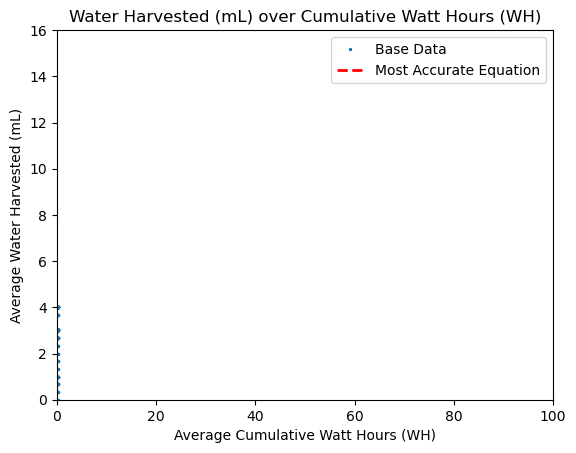

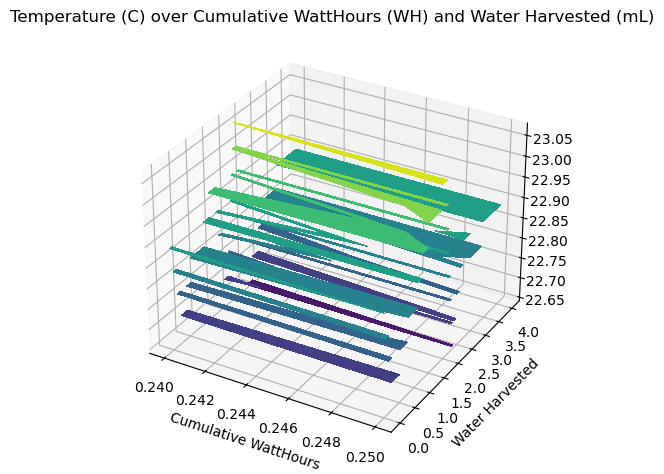

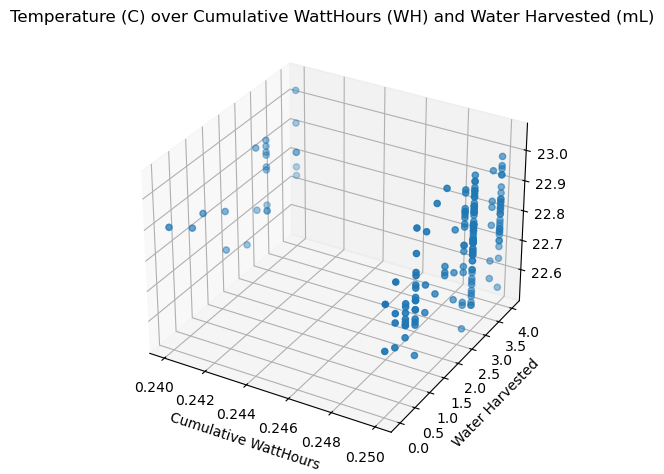

In [16]:
#Basic scatter plot
plt.plot(
    DC_x,
    DC_y,
    linewidth=2,
    linestyle="none",
    marker="*",
    label="Base Data",
    fillstyle="none",
    markersize=2,
)

#Fit the equation to the data
best_idx = DepControl_Equations.equations_.query(
    f"loss < {2 * DepControl_Equations.equations_.loss.min()}"
).score.idxmax()
plt.plot(
    DC_x,
    DepControl_Equations.predict(DC_x, index=best_idx),
    color="red",
    linestyle="dashed",
    linewidth=2,
    label="Most Accurate Equation",
)
plt.title("Water Harvested (mL) over Cumulative Watt Hours (WH)")
plt.xlabel("Average Cumulative Watt Hours (WH)")
plt.ylabel("Average Water Harvested (mL)")
plt.legend()
plt.xlim([0, 100])
plt.ylim([0, 16])
analysis(
    [
        pd.to_numeric(
            DepControl_Dataframe["WattHours (WH)"].str.replace(
                r"[^0-9\.\-\+]", "", regex=True
            )
        ).to_numpy(),
        DC_z,
        pd.to_numeric(
            DepControl_Dataframe["Amps (A)"].str.replace(
                r"[^0-9\.\-\+]", "", regex=True
            )
        ).to_numpy(),
        DC_y,
    ]
)
print(DepControl_Equations.latex())

#3D scatterplot and contour plot
fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours", loc="left")
plt.ylabel("Water Harvested")
fig.tight_layout()
DC_X, DC_Y = np.meshgrid(DC_x,DC_y)
DC_Z = sp.interpolate.griddata(np.column_stack((DC_x.reshape(-1,1),DC_y)), DC_z, (DC_X, DC_Y), method = "nearest")
plt.contourf(DC_x.reshape(-1),DC_y,DC_Z)

fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours")
plt.ylabel("Water Harvested")
fig.tight_layout()
ax.scatter3D(DC_x,DC_y,DC_z)

In [ ]:
#Run PySR
DepProto_Equations = PySRRegressor(
    **default_pysr_params,
)

#Fit an equation to the data
DepProto_Equations.fit(DP_x,DP_y)

In [ ]:
#Basic scatter plot
plt.plot(
    DP_x,
    DP_y,
    linewidth=2,
    linestyle="none",
    marker="*",
    label="Base Data",
    fillstyle="none",
    markersize=2,
)

#Fit the equation to the data
best_idx = DepProto_Equations.equations_.query(
    f"loss < {2 * DepProto_Equations.equations_.loss.min()}"
).score.idxmax()
plt.plot(
    DP_x,
    DepProto_Equations.predict(DP_x, index=best_idx),
    color="red",
    linestyle="dashed",
    linewidth=2,
    label="Most Accurate Equation",
)
plt.title("Water Harvested (mL) over Cumulative Watt Hours (WH)")
plt.xlabel("Average Cumulative Watt Hours (WH)")
plt.ylabel("Average Water Harvested (mL)")
plt.legend()
plt.xlim([0, 100])
plt.ylim([0, 16])
analysis(
    [
        pd.to_numeric(
            DepProto_Dataframe["WattHours (WH)"].str.replace(
                r"[^0-9\.\-\+]", "", regex=True
            )
        ).to_numpy(),
        DP_z,
        pd.to_numeric(
            DepProto_Dataframe["Amps (A)"].str.replace(
                r"[^0-9\.\-\+]", "", regex=True
            )
        ).to_numpy(),
        DP_y,
    ]
)
print(DepProto_Equations.latex())

#3D scatterplot
fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours", loc="left")
plt.ylabel("Water Harvested")
fig.tight_layout()
DP_X, DP_Y = np.meshgrid(DP_x,DP_y)
DP_Z = sp.interpolate.griddata(np.column_stack((DP_x.reshape(-1,1),DP_y)), DP_z, (DP_X, DP_Y), method = "nearest")
plt.contourf(DP_x.reshape(-1),DP_y,DP_Z)

fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours")
plt.ylabel("Water Harvested")
fig.tight_layout()
ax.scatter3D(DP_x,DP_y,DP_z)